In [40]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [41]:
df = pd.read_csv("Wholesale customers data.csv")
df.head(5)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [42]:
df.shape[1], df.shape[0]

(8, 440)

In [43]:
df.columns

Index(['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen'],
      dtype='object')

In [44]:
df.dtypes

Channel             int64
Region              int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
dtype: object

In [45]:
df[['Channel','Region']] = df[['Channel','Region']].astype('category')

In [46]:
num_cols = ['Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']
df[num_cols].skew()

Fresh                2.561323
Milk                 4.053755
Grocery              3.587429
Frozen               5.907986
Detergents_Paper     3.631851
Delicassen          11.151586
dtype: float64

# EDA

In [47]:
df.describe()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


## Univariate Analysis

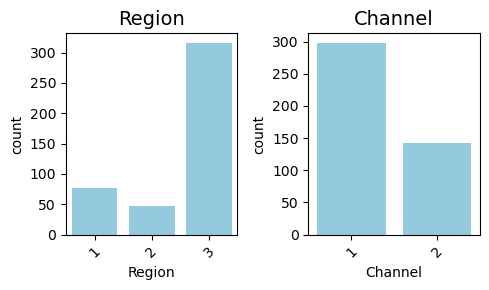

In [48]:
col = ['Region','Channel']
fig,axs = plt.subplots(1,2, figsize=(5,3))
axs = axs.flatten()

for i,a in enumerate(col):
    sns.countplot(data=df,x=a,ax=axs[i],color='skyblue')
    axs[i].set_title(a, fontsize=14)
    axs[i].tick_params(axis='x', rotation=45)

plt.tight_layout()  
plt.show()

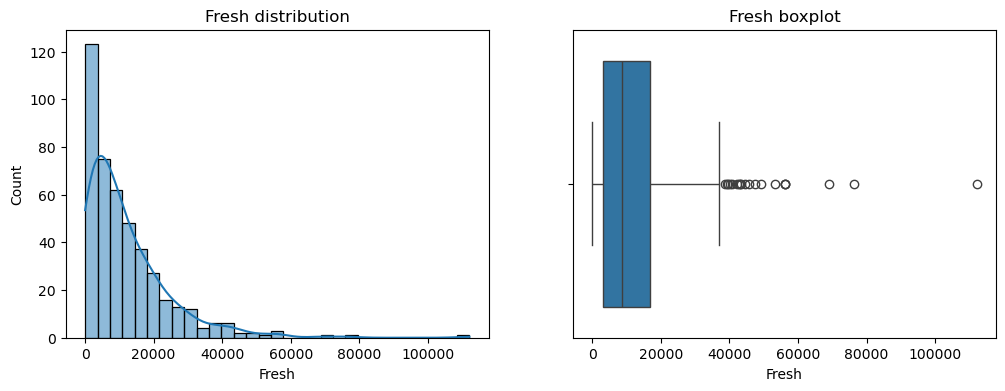

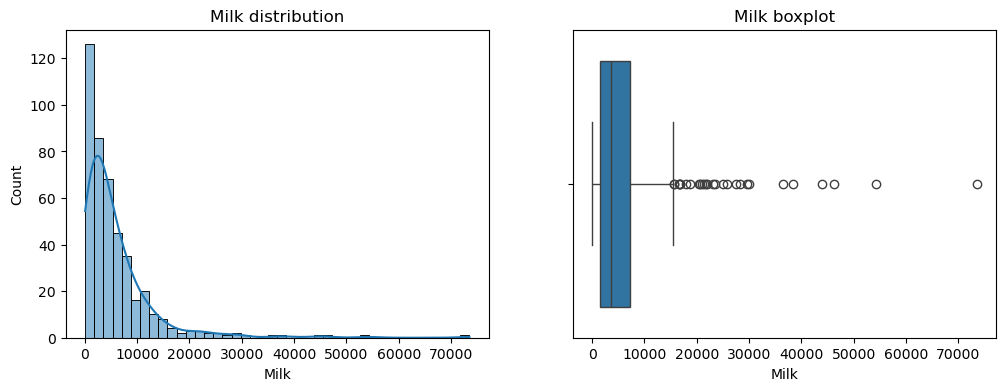

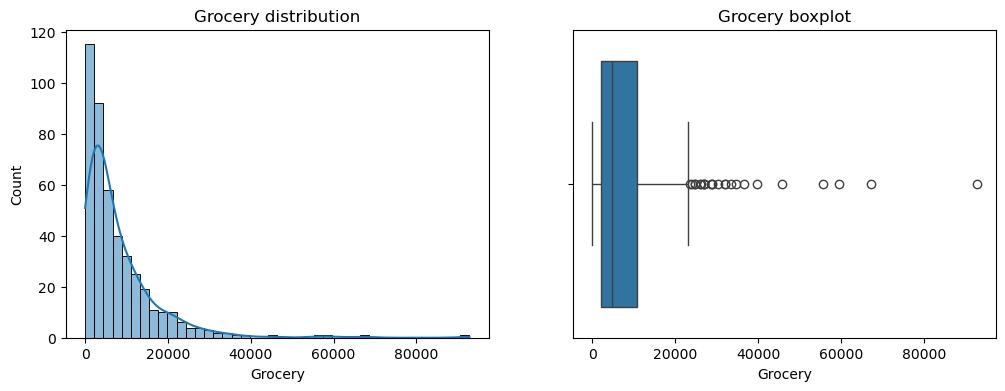

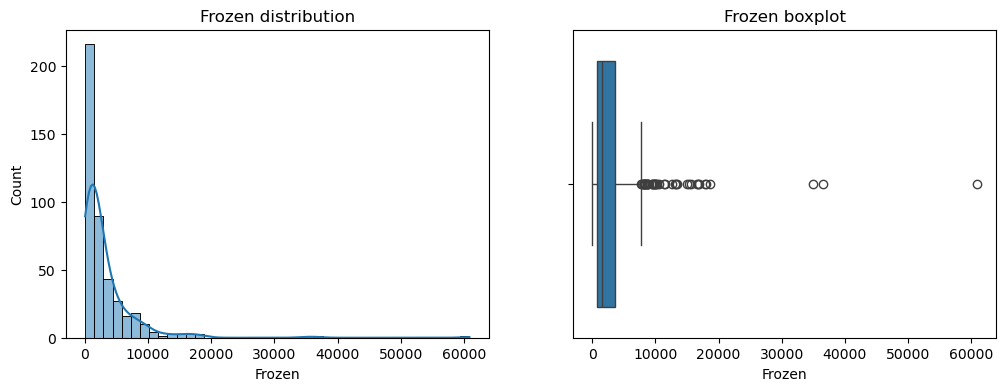

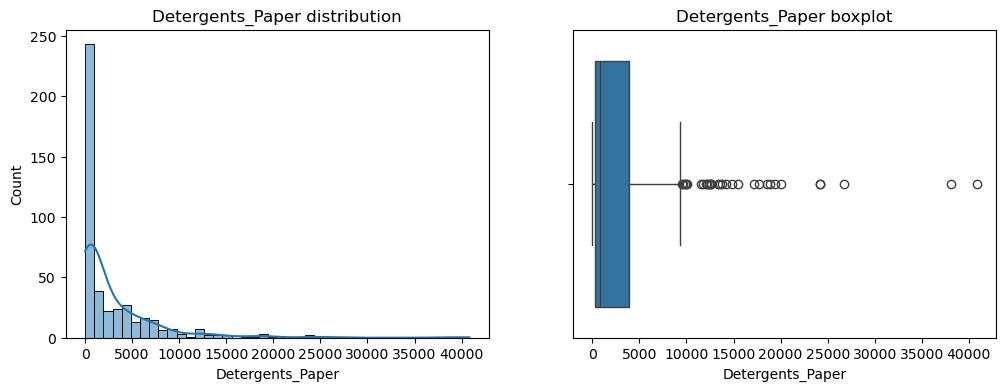

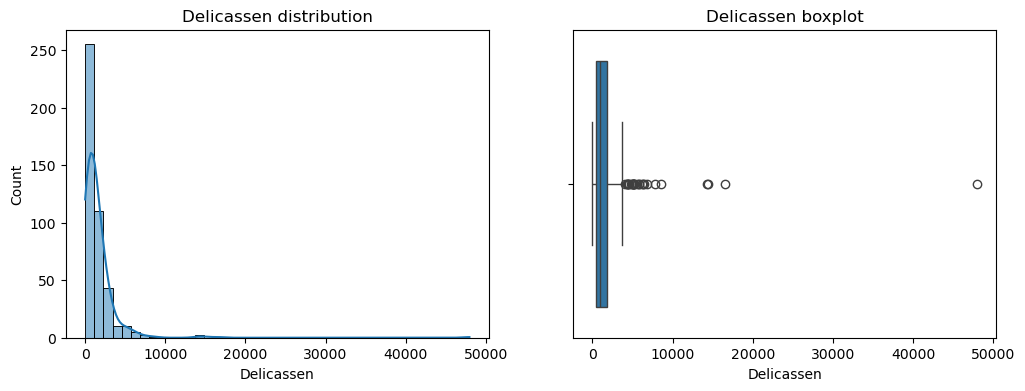

In [49]:
num_cols = ['Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']

for col in num_cols:
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True)
    plt.title(f'{col} distribution')
    
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f'{col} boxplot')
    plt.show()


almost all of them are right skewed


## Bivariate Analysis

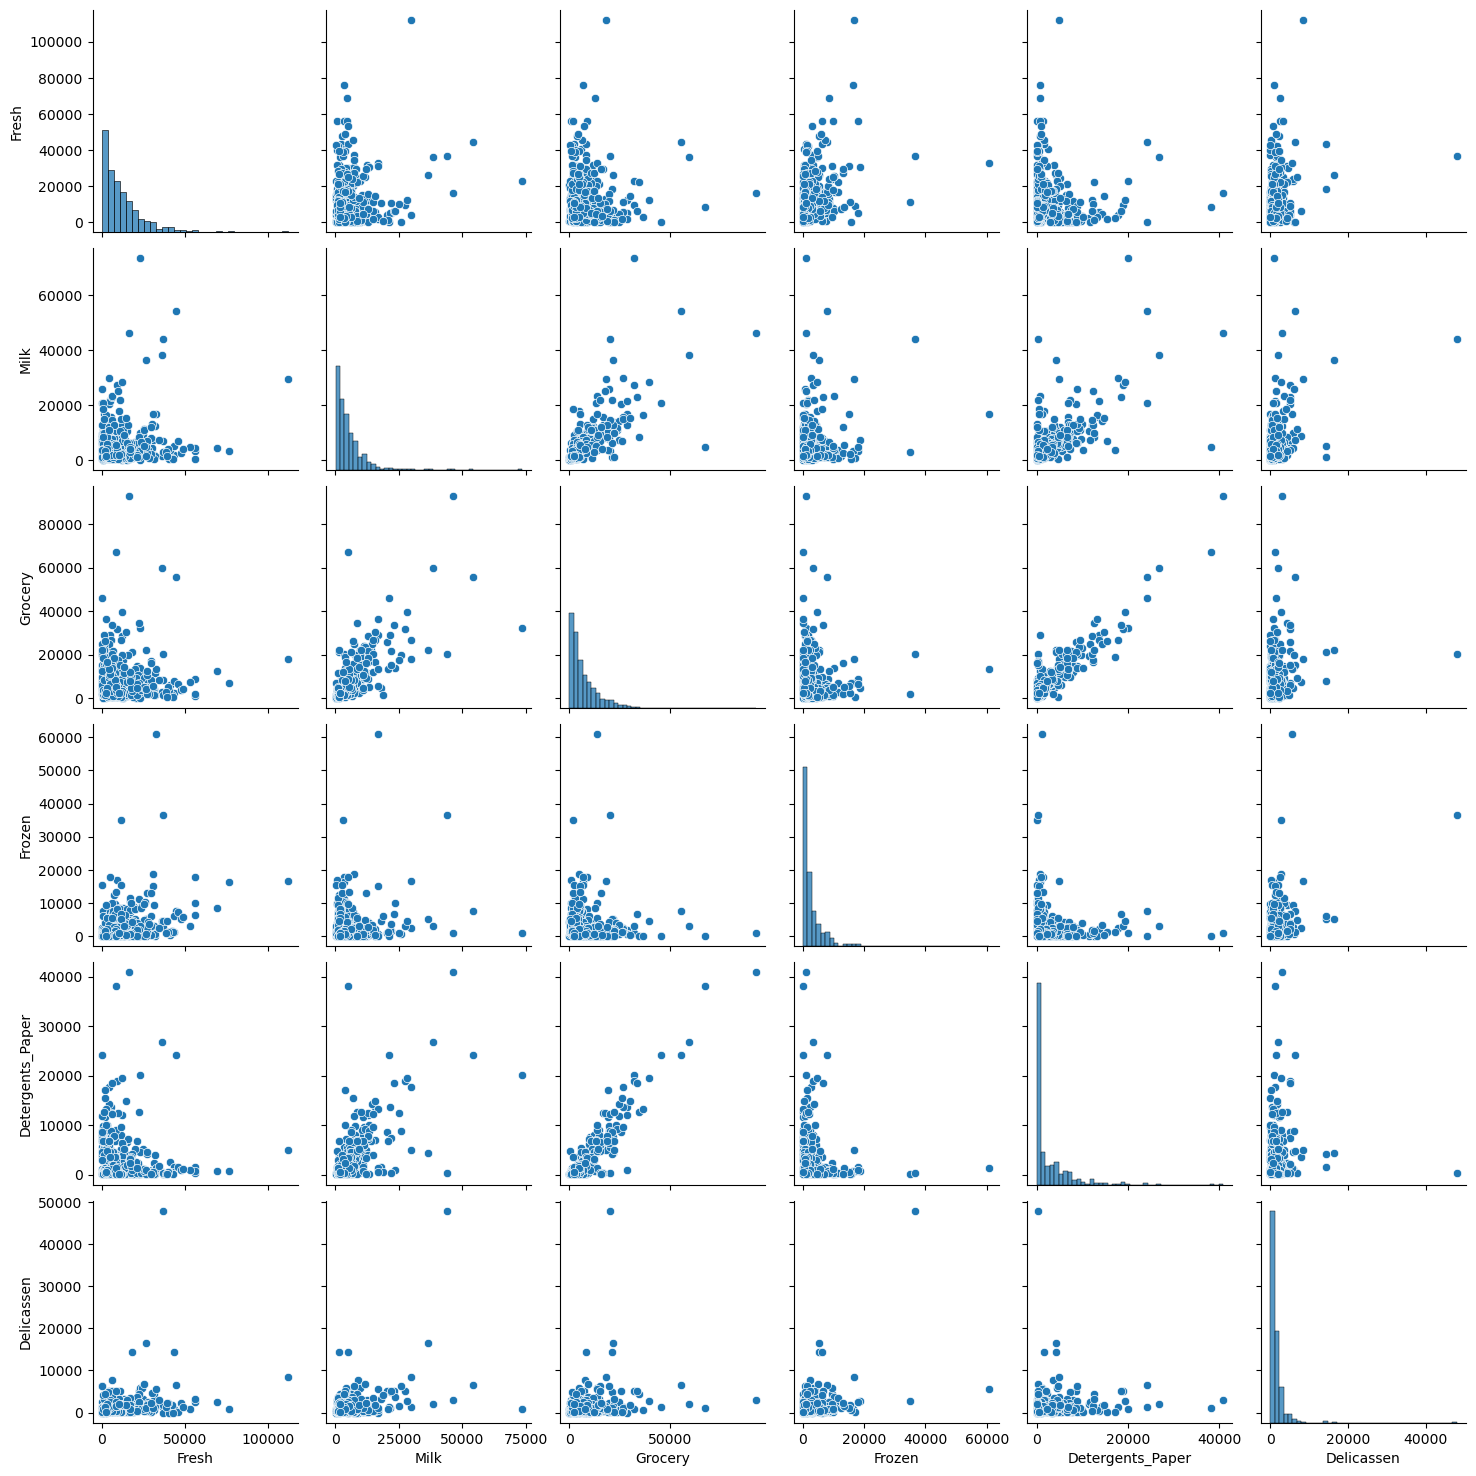

In [50]:
sns.pairplot(df[num_cols])


<Axes: >

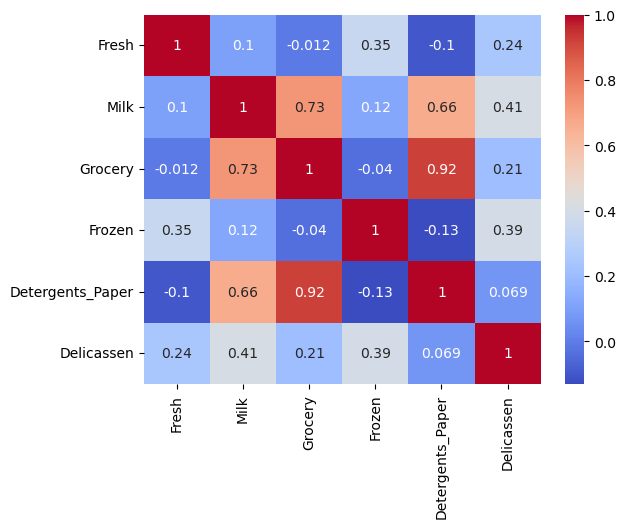

In [51]:
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')


could see milk and groceries etc highly correlated. it needs Dimentionallisty reduction to avoid Multicollinearity

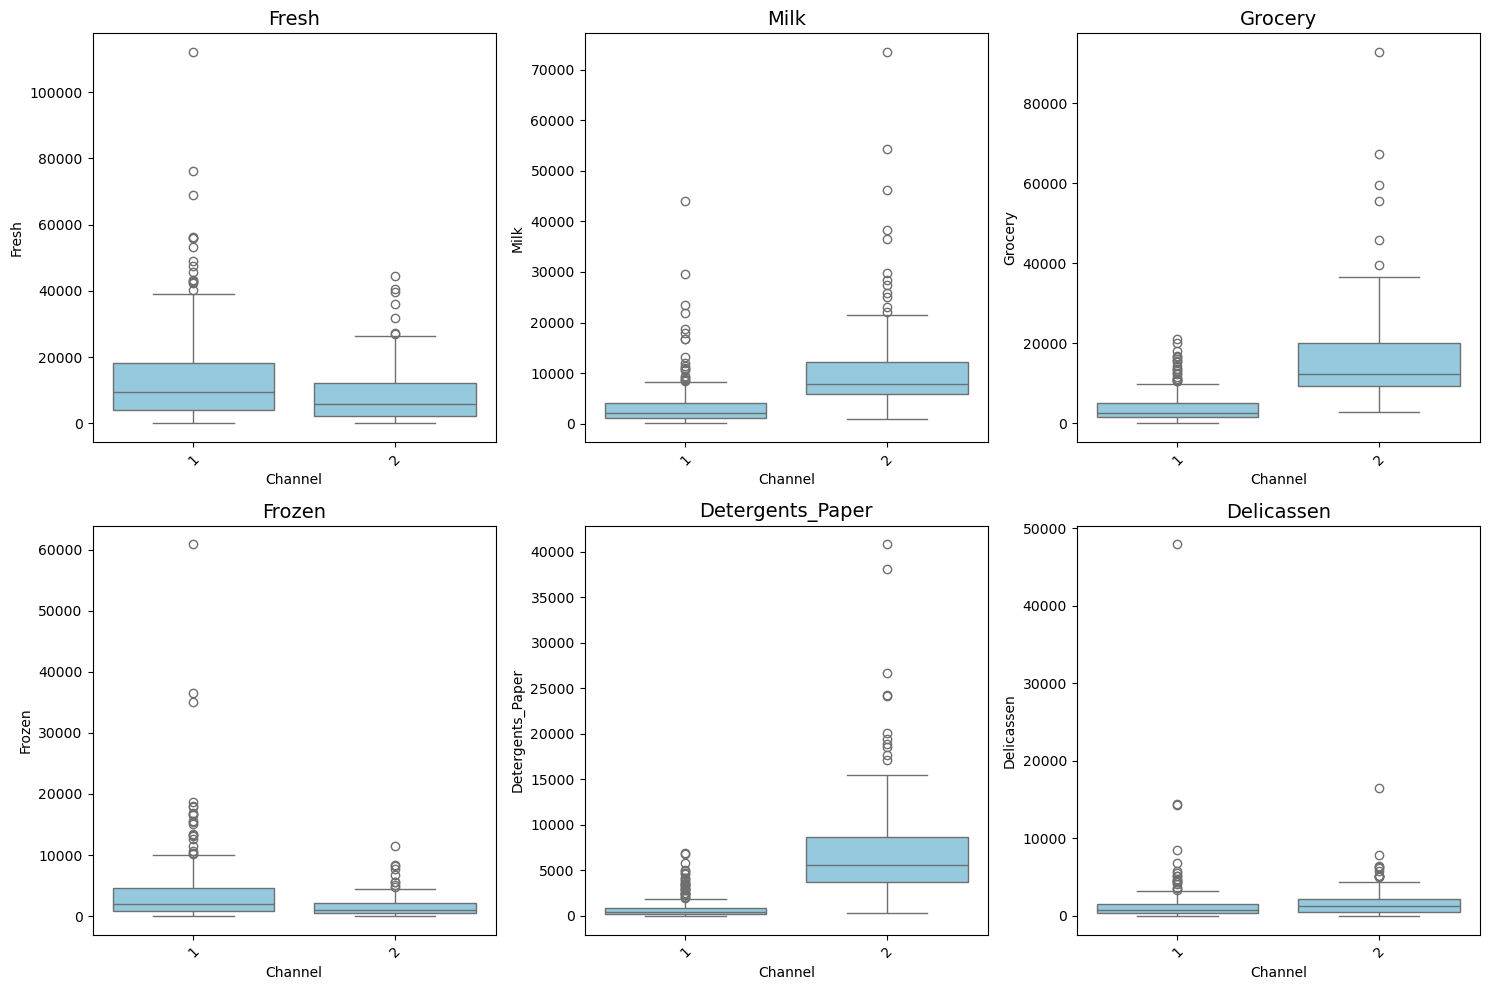

In [52]:
num_cols = ['Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']

fig, axs = plt.subplots(2, 3, figsize=(15, 10))  
axs = axs.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x='Channel', y=col, data=df, ax=axs[i], color='skyblue')
    axs[i].set_title(col, fontsize=14)
    axs[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

outliers visible.

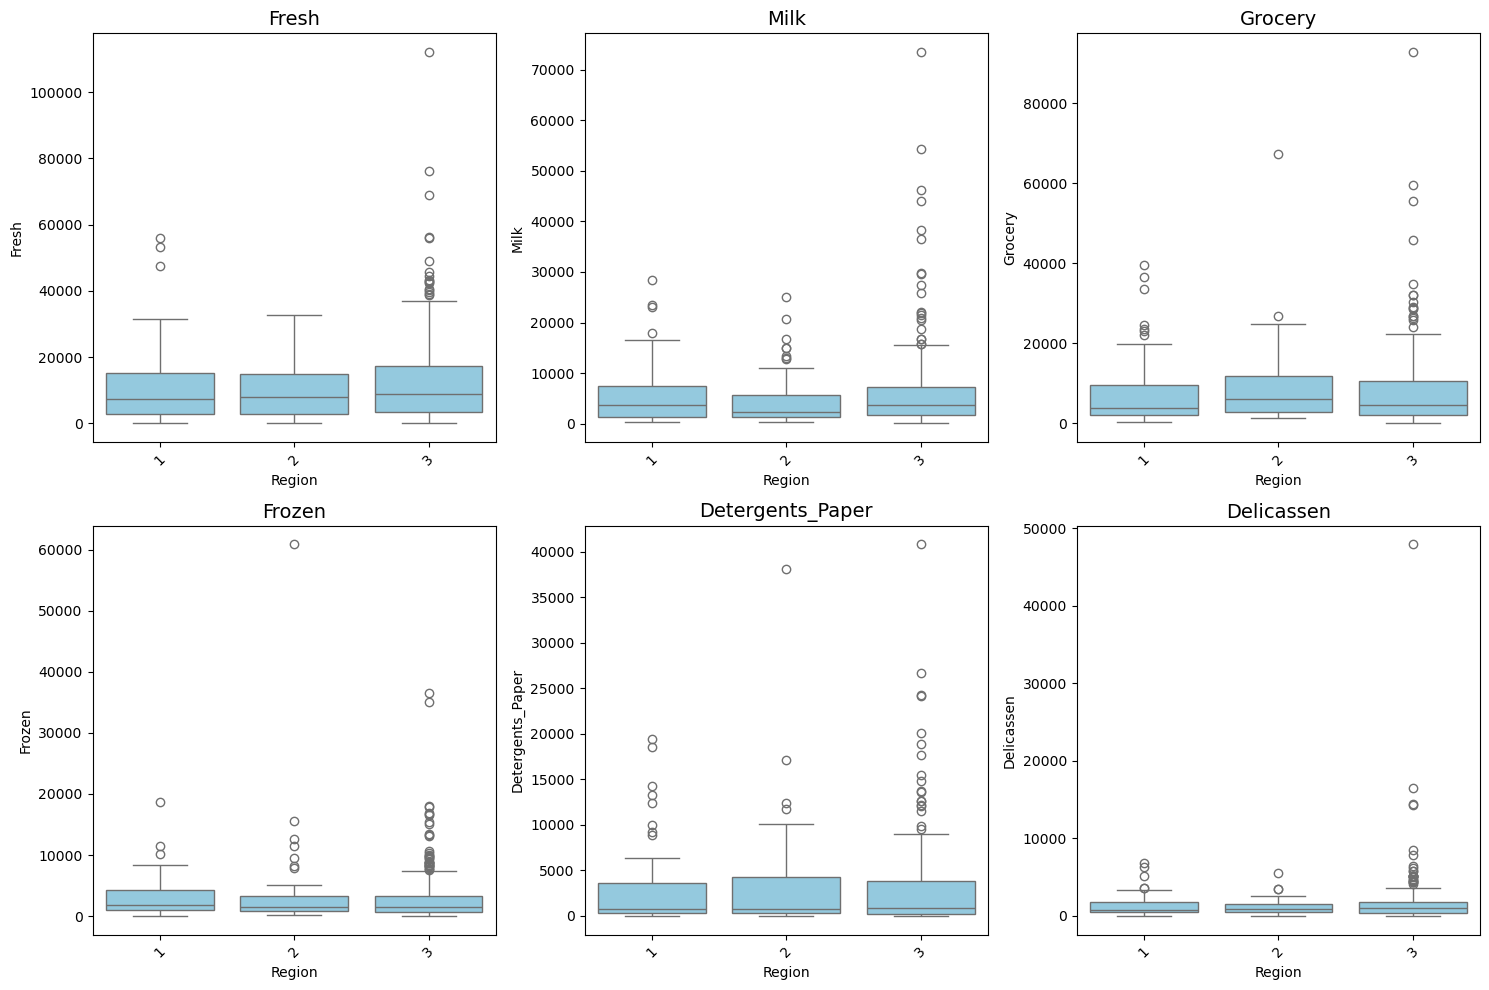

In [53]:
num_cols = ['Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']

fig, axs = plt.subplots(2, 3, figsize=(15, 10))  
axs = axs.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x='Region', y=col, data=df, ax=axs[i], color='skyblue')
    axs[i].set_title(col, fontsize=14)
    axs[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Data cleaning

In [54]:
df.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [55]:
df.duplicated().sum()

np.int64(0)

In [56]:
def outlier_cleaning(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR  # plus for upper

        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df

outlier_features = ['Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']
df = outlier_cleaning(df, outlier_features)


In [57]:
df = df.reset_index(drop=True)

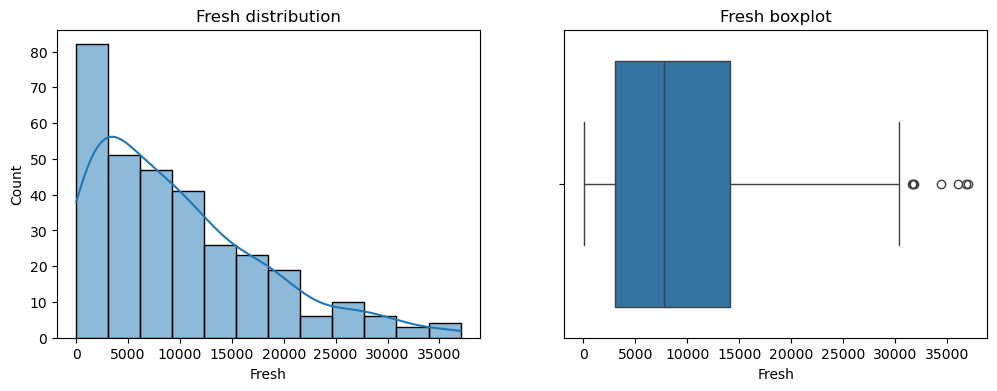

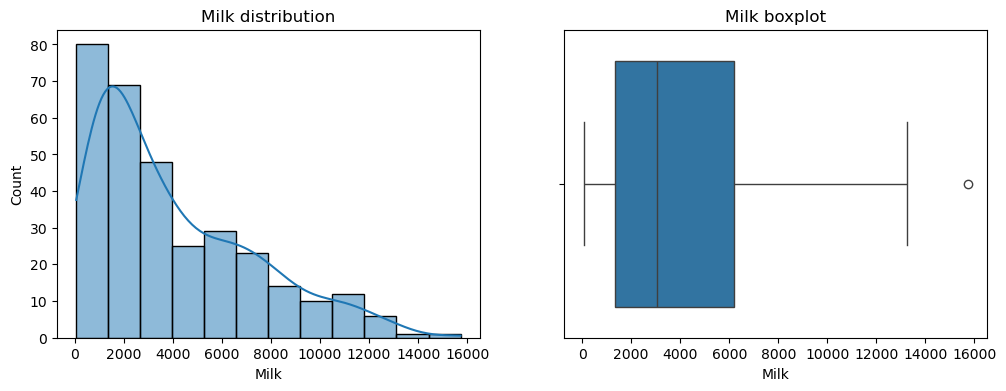

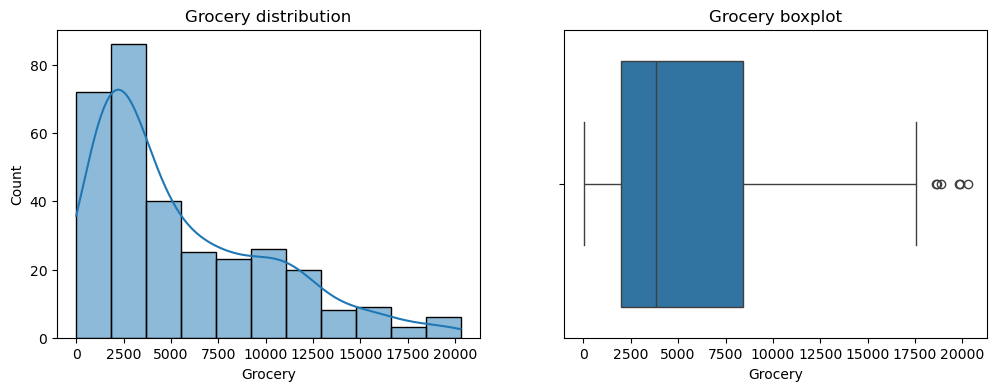

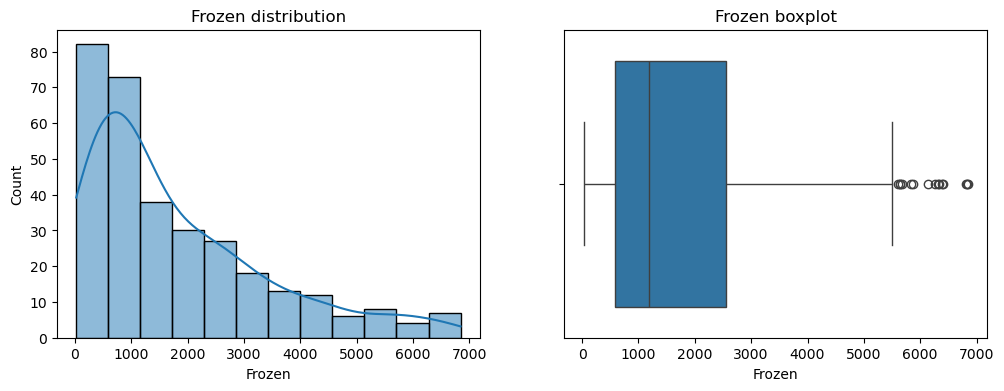

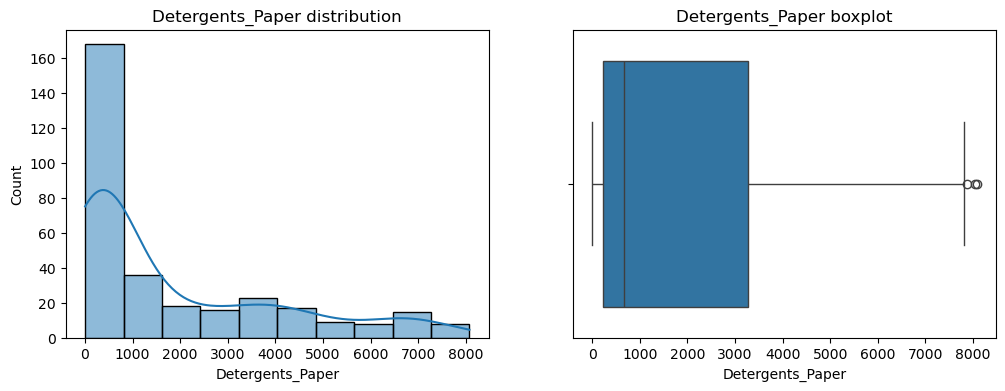

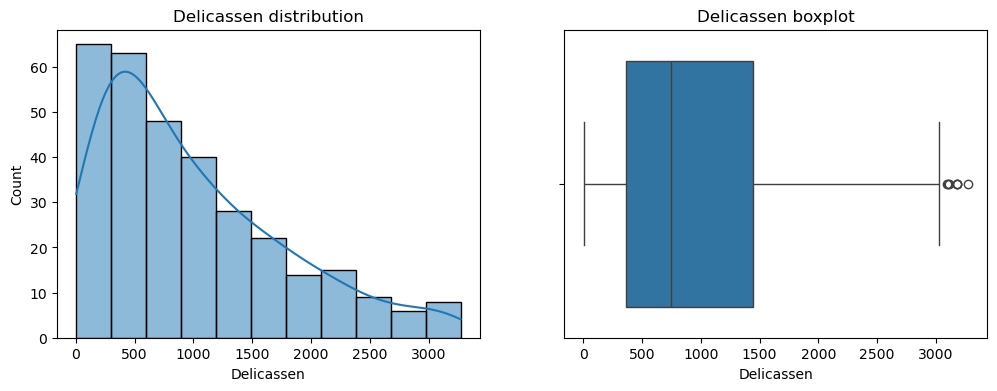

In [58]:
num_cols = ['Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']

for col in num_cols:
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True)
    plt.title(f'{col} distribution')
    
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f'{col} boxplot')
    plt.show()  


# feature engineering

In [59]:
df.head(3)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,1,3,13265,1196,4221,6404,507,1788


In [60]:
num_cols = ['Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']
df[num_cols].skew()

Fresh               1.063799
Milk                1.024379
Grocery             1.076064
Frozen              1.244689
Detergents_Paper    1.248694
Delicassen          0.988599
dtype: float64

In [61]:
from scipy.stats import boxcox
num_cols = ['Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']
df_boxcox = df.copy()

for col in num_cols:
    df_boxcox[col], _ = boxcox(df_boxcox[col] + 1)  # add 1 to avoid zero values

print(df_boxcox[num_cols].skew())


Fresh              -0.125656
Milk               -0.050617
Grocery            -0.022628
Frozen             -0.057423
Detergents_Paper   -0.051290
Delicassen         -0.076684
dtype: float64


used the Box-Cox transformation because the variables were heavily right-skewed, and Box-Cox works well on strictly positive values, helping normalize the distributions for better modeling.

In [62]:
df_boxcox.head(2)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,89.759269,30.889839,35.211127,11.338536,12.809115,37.671071
1,2,3,71.533052,31.016652,37.669581,21.981479,13.327965,42.229187


In [63]:
df_oh = pd.get_dummies(df_boxcox,columns=['Channel','Region'], drop_first=False, dtype=int )

In [64]:
df_oh.head(5)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Channel_1,Channel_2,Region_1,Region_2,Region_3
0,89.759269,30.889839,35.211127,11.338536,12.809115,37.671071,0,1,0,0,1
1,71.533052,31.016652,37.669581,21.981479,13.327965,42.229187,0,1,0,0,1
2,91.368106,17.581058,29.732255,31.893466,9.082108,42.343642,1,0,0,0,1
3,80.006398,29.661487,31.466787,16.367054,11.849832,38.926486,0,1,0,0,1
4,88.251816,23.071789,34.402636,14.765793,13.208322,26.064641,0,1,0,0,1


In [65]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled_num = pd.DataFrame(
    scaler.fit_transform(df_oh[num_cols]),
    columns=num_cols
)
categorical_cols = df_oh.columns.difference(num_cols)

df_final = pd.concat([df_scaled_num, df_oh[categorical_cols]], axis=1)


used StandardScaler because K-Means relies on distance calculations, and scaling ensures all features contribute equally by putting them on the same standard normal scale.

In [66]:
df_final.head(5)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Channel_1,Channel_2,Region_1,Region_2,Region_3
0,0.589432,1.457222,0.683807,-1.406379,0.823889,0.647879,0,1,0,0,1
1,-0.041898,1.479650,0.988679,0.320178,0.978473,1.044342,0,1,0,0,1
2,0.645160,-0.896486,0.004374,1.928156,-0.286522,1.054297,1,0,0,0,1
3,0.251607,1.239984,0.219473,-0.590625,0.538083,0.757074,0,1,0,0,1
4,0.537216,0.074570,0.583547,-0.850391,0.942827,-0.361644,0,1,0,0,1


In [67]:
categorical_cols = df_oh.columns.difference(num_cols)
df_cat = df_oh[categorical_cols].reset_index(drop=True)


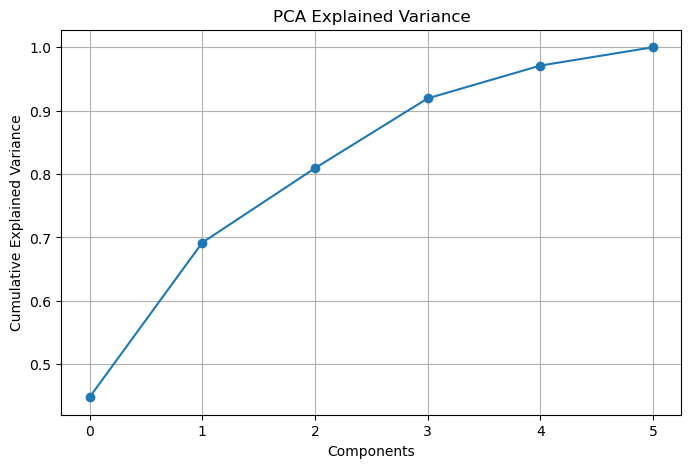

In [68]:
from sklearn.decomposition import PCA
pca_full = PCA()
pca_full.fit(df_scaled_num)

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o')
plt.xlabel("Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid()
plt.show()


I used PCA because some features like Milk and Grocery were highly correlated (around 0.75), and PCA helps remove multicollinearity by converting correlated variables into independent components.

In [69]:
pca = PCA(n_components=2)
pca_num = pca.fit_transform(df_scaled_num)

pca_df = pd.DataFrame(pca_num, columns=['PC1', 'PC2'])


In [70]:
df_final = pd.concat([pca_df, df_cat], axis=1)

e:\downloads\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
e:\downloads\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
e:\downloads\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
e:\downloads\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

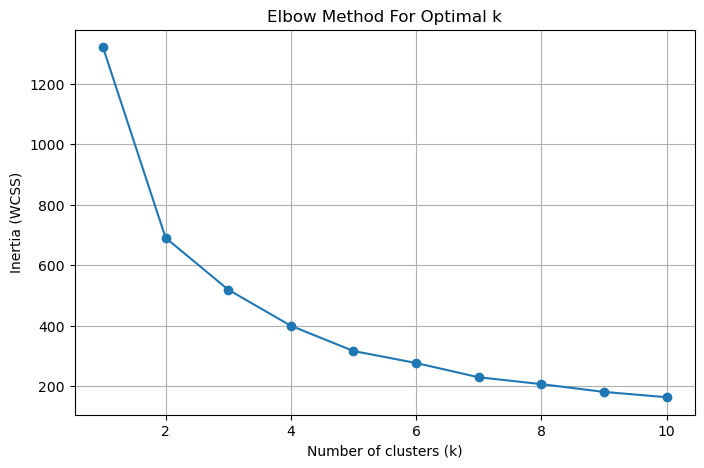

In [71]:
from sklearn.cluster import KMeans

inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_final[['PC1','PC2']])
    inertia.append(kmeans.inertia_)  # WCSS
plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method For Optimal k")
plt.grid()
plt.show()


e:\downloads\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
e:\downloads\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


e:\downloads\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
e:\downloads\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
e:\downloads\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
e:\downloads\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

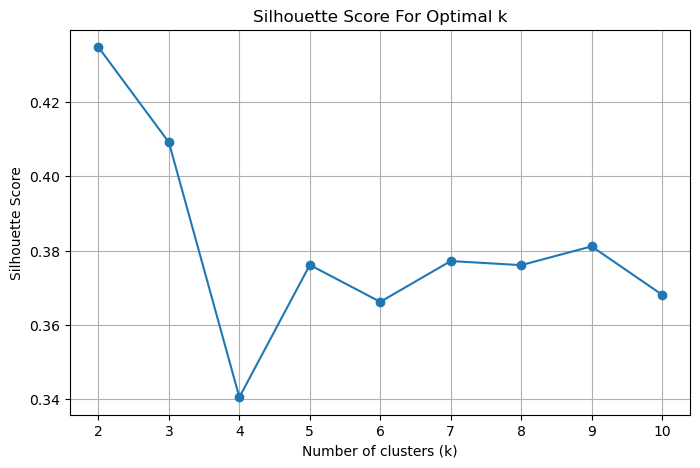

In [72]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_final[['PC1','PC2']])
    sil = silhouette_score(df_final[['PC1','PC2']], labels)
    sil_scores.append(sil)
plt.figure(figsize=(8,5))
plt.plot(range(2, 11), sil_scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score For Optimal k")
plt.grid()
plt.show()


In [73]:
kmeans = KMeans(n_clusters=2, random_state=42)
df_final['Cluster'] = kmeans.fit_predict(df_final[['PC1','PC2']])


e:\downloads\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


selecting number of cluster as 2 refering silhouette score and elbow method

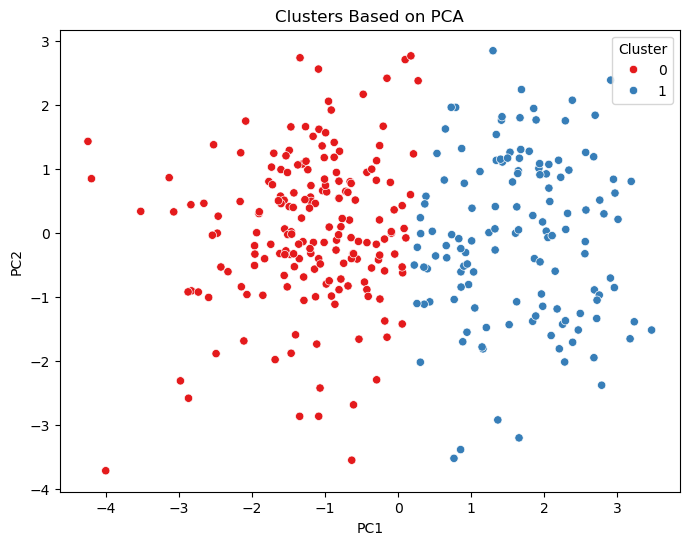

In [74]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_final,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1'
)
plt.title("Clusters Based on PCA")
plt.show()


In [75]:
print("\nRegion vs Cluster:")
print(df_final.groupby('Cluster')[['Region_1','Region_2','Region_3']].sum())



Region vs Cluster:
         Region_1  Region_2  Region_3
Cluster                              
0              38        20       126
1              17        10       107


In [76]:
print("\nChannel vs Cluster:")
print(df_final.groupby('Cluster')[['Channel_1','Channel_2']].sum())



Channel vs Cluster:
         Channel_1  Channel_2
Cluster                      
0              182          2
1               50         84


In [77]:
cluster_profile = df_final.groupby('Cluster').mean()
cluster_profile


,PC1,PC2,Channel_1,Channel_2,Region_1,Region_2,Region_3
Cluster,,,,,,,
0,-1.200108,0.049839,0.989130,0.010870,0.206522,0.108696,0.684783
1,1.647910,-0.068436,0.373134,0.626866,0.126866,0.074627,0.798507
